In [1]:
import pygrib
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

In [1]:
import datetime
import pygrib
import numpy as np

filename_1 = "./EGG4/c680c6abfed449d6ac9992c57a7f6c2d.grib"
filename_2 = "./EGG4/41f26c030437d80ad6b4886fcc0aad4a_mean_column.grib"

# Open both GRIB files
grbs1 = pygrib.open(filename_1)
grbs2 = pygrib.open(filename_2)

# Pre-process grbs1 to avoid repeated iterating
# Create a dictionary indexed by date for faster lookups
level_data = {}
for grb_level in grbs1:
    level_date = datetime.datetime(grb_level.year, grb_level.month, grb_level.day)
    level = grb_level.level
    
    # Store the level data indexed by date
    if level_date not in level_data:
        level_data[level_date] = {}
    
    # Cache the processed values to avoid recomputation
    level_data[level_date][level] = np.array(grb_level.values) * 1E9



# # Close the GRIB files
grbs1.close()
grbs2.close()

In [2]:
dates = []
mean_colmn_tensor = []
for date in level_data.keys():

    colmn_sum = np.zeros(level_data[date][1].shape)
    prev_level = 0
    
    for level, value in sorted(level_data[date].items()):

        deltaP = level - prev_level
        prev_level = level
        colmn_sum += deltaP * value
        
    # Append to result arrays
    dates.append(date)
    mean_colmn_i = colmn_sum/1000
    mean_colmn_tensor.append(mean_colmn_i)

In [3]:
# Process mean column data
all_dates = []
ratios_tensor = []
mean_ratios = []
heights = []

for i, mean_column in enumerate(mean_colmn_tensor):
    mean_date = dates[i]

    if mean_date in level_data:
        # Process all relevant levels for this date
        
        for level, value in sorted(level_data[mean_date].items()):
            # Calculate ratio once
            ratio = np.divide(value, mean_column)
            print(f"Valor max: {value.max()} min: {value.min()} a presión: {level} hPa")
            # Append to result arrays
            all_dates.append(mean_date)
            ratios_tensor.append(ratio)
            mean_ratios.append(np.mean(ratio))
            heights.append(level)
    else:
        raise("NoDateError: no se encontró la fecha")
                    

Valor max: 294.4435220086916 min: 274.57343954040425 a presión: 1 hPa
Valor max: 490.1755872310787 min: 373.5091027579074 a presión: 2 hPa
Valor max: 519.9574815151209 min: 347.19033692454104 a presión: 3 hPa
Valor max: 574.9885332306803 min: 482.79480324708857 a presión: 5 hPa
Valor max: 669.7122891807794 min: 621.6716066376193 a presión: 7 hPa
Valor max: 810.4805999664677 min: 748.8346298600845 a presión: 10 hPa
Valor max: 880.8544613714275 min: 838.187769858223 a presión: 20 hPa
Valor max: 908.1649494646626 min: 872.8452876027859 a presión: 30 hPa
Valor max: 955.247013934013 min: 918.0837210465143 a presión: 50 hPa
Valor max: 977.9666747533611 min: 961.6756297958773 a presión: 70 hPa
Valor max: 984.8252013888725 min: 977.949852654092 a presión: 100 hPa
Valor max: 991.6730032699661 min: 974.2694935255258 a presión: 150 hPa
Valor max: 992.74567766372 min: 976.929738882859 a presión: 200 hPa
Valor max: 990.8690961069055 min: 977.5298499548057 a presión: 250 hPa
Valor max: 988.683581226

In [21]:
dates[0]

datetime.datetime(2002, 12, 31, 0, 0)

In [14]:
# Define your date range

# Convert lists to NumPy arrays if they aren't already
dates_array = np.array(all_dates)
ratios_array = np.array(ratios_tensor)
heights_array = np.array(heights)
mean_ratios_array = np.array(mean_ratios)

def get_filtered_data(date):    
    # Create a mask for the date range
    date_mask = (dates_array == date)
    
    # Apply the mask to filter the arrays
    filtered_ratios = ratios_array[date_mask]
    filtered_heights = heights_array[date_mask]
    filtered_dates = dates_array[date_mask]
    filtered_mean_ratios = mean_ratios_array[date_mask]

    return filtered_dates, filtered_heights, filtered_dates, filtered_mean_ratios

In [6]:


print(f"Fecha: {filtered_dates[0]} \n")
for i, ratio in enumerate(filtered_ratios):
    print("------------------------------------------------")
    print(f"max ratio: {np.max(ratio):.4f} - min ratio: {np.min(ratio):.4f}")
    print(f"Mean ratio: {np.mean(ratio):.4f}")
    print(f"pressure: {filtered_heights[i]} hPa")

Fecha: 2020-11-30 00:00:00 

------------------------------------------------
max ratio: 0.3434 - min ratio: 0.2753
Mean ratio: 0.3209
pressure: 1 hPa
------------------------------------------------
max ratio: 0.4045 - min ratio: 0.3285
Mean ratio: 0.3669
pressure: 2 hPa
------------------------------------------------
max ratio: 0.4714 - min ratio: 0.3978
Mean ratio: 0.4313
pressure: 3 hPa
------------------------------------------------
max ratio: 0.6129 - min ratio: 0.5417
Mean ratio: 0.5749
pressure: 5 hPa
------------------------------------------------
max ratio: 0.7300 - min ratio: 0.6577
Mean ratio: 0.6950
pressure: 7 hPa
------------------------------------------------
max ratio: 0.8526 - min ratio: 0.7770
Mean ratio: 0.8242
pressure: 10 hPa
------------------------------------------------
max ratio: 0.9702 - min ratio: 0.8688
Mean ratio: 0.9360
pressure: 20 hPa
------------------------------------------------
max ratio: 0.9787 - min ratio: 0.8932
Mean ratio: 0.9542
pressure:

In [22]:
len(dates)

216

In [25]:
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

# Define start and end dates
start_date = dates[0]
end_date = dates[-1]

# Method 1: Using dateutil's relativedelta (recommended)
current = start_date

mean_ratios_1000 = []
while current <= end_date:
    current += relativedelta(months=1)
    filtered_dates, filtered_heights, filtered_dates, filtered_mean_ratios = get_filtered_data(current)
    mean_ratio_1000 = np.mean(filtered_ratios[-1])
    mean_ratios_1000.append(mean_ratio_1000)

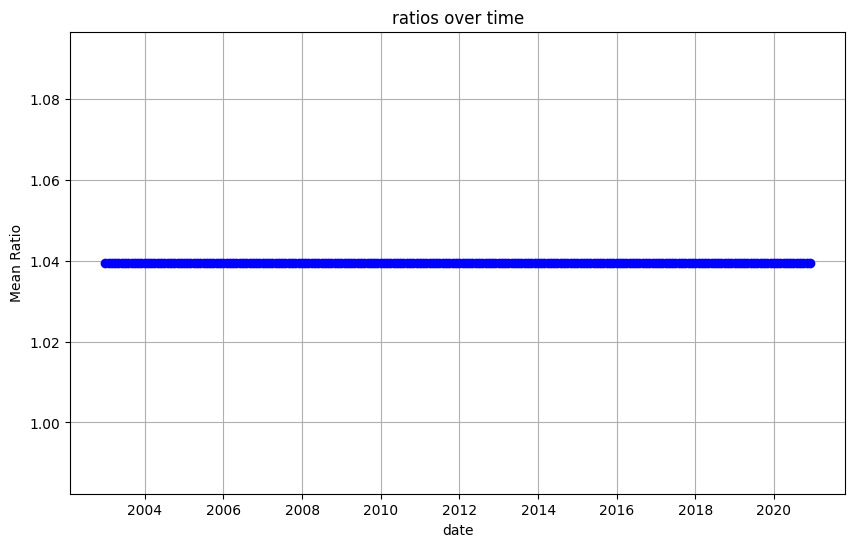

In [26]:
import matplotlib.pyplot as plt

# Crear la gráfica
plt.figure(figsize=(10, 6))
plt.plot(dates, mean_ratios_1000, marker='o', linestyle='-', color='b')

# Configurar ejes y título
plt.xlabel('date')
plt.ylabel('Mean Ratio')
plt.title('ratios over time')
plt.grid(True)

# Mostrar la gráfica
plt.show()

In [27]:
mean_ratios_1000 = np.array(mean_ratios_1000)
np.mean(mean_ratios_1000)

1.0395307027448444

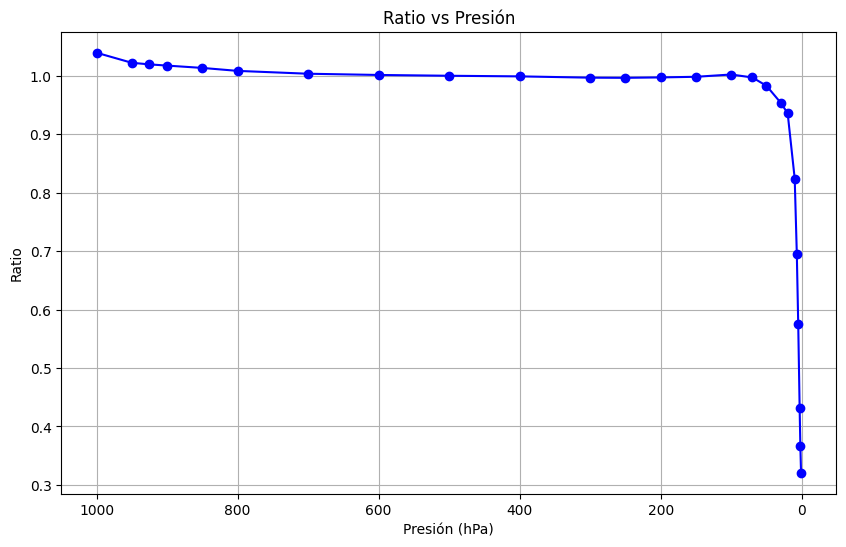

In [24]:
import matplotlib.pyplot as plt

# Crear la gráfica
plt.figure(figsize=(10, 6))
plt.plot(filtered_heights, filtered_mean_ratios, marker='o', linestyle='-', color='b')

# Configurar ejes y título
plt.xlabel('Presión (hPa)')
plt.ylabel('Ratio')
plt.title('Ratio vs Presión')
plt.gca().invert_xaxis()  # Invertir el eje x para que la presión disminuya hacia la derecha
plt.grid(True)

# Mostrar la gráfica
plt.show()